# Numerical Project in Python — Cooperative Kernel regression  


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

# Setup figure style (readable in PDF)
plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

sigma = 0.5
nu = 1.0

DATA_PATH = Path("first_database.pkl")

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
 

def load_first_database(path: Path):
    with open(path, "rb") as f:
        x, y = pickle.load(f)
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    return x, y

x_all, y_all = load_first_database(DATA_PATH)
print("N total =", len(x_all))

N total = 1000000


/var/folders/p9/b0lp42q57j97t4297lz4fct00000gn/T/ipykernel_3698/2019281057.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x, y = pickle.load(f)


## Visualize the data


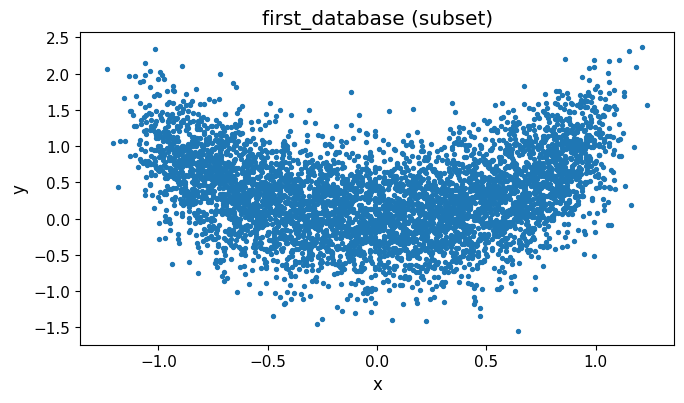

Saved: fig_data_subset.pdf


In [3]:
N_plot = min(5000, len(x_all))
plt.figure()
plt.scatter(x_all[:N_plot], y_all[:N_plot], s=8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("first_database (subset)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_data_subset.pdf", format="pdf")
plt.show()
print("Saved: fig_data_subset.pdf")

### Param n / m

In [4]:
# Parameters from the statement
n = 100
m = 10
a = 5
assert n % a == 0
n_per_agent = n // a

# First n points
x = x_all[:n].copy()
y = y_all[:n].copy()

rng = np.random.default_rng(1)
sel = [i for i in range(n)]
ind = rng.choice(sel, m, replace=False)
x_selected = np.array([x[i] for i in ind])

print("n =", n, "| m =", m, "| a =", a, "| points/agent =", n_per_agent)


n = 100 | m = 10 | a = 5 | points/agent = 20


##  Define the kernel and build the matrices `Kmm` and `Knm`



In [5]:
def k_euclidean(x1, x2):
    return np.exp(-(x1 - x2)**2)

def K_nm(x_points, x_m_points):
    x_points = np.asarray(x_points).reshape(-1, 1)   # (n,1)
    x_m_points = np.asarray(x_m_points).reshape(1, -1)  # (1,m)
    return np.exp(-(x_points - x_m_points)**2)

Kmm = K_nm(x_selected, x_selected)   # (m,m)
Knm = K_nm(x, x_selected)            # (n,m)

print("Kmm:", Kmm.shape, "| Knm:", Knm.shape)

Kmm: (10, 10) | Knm: (100, 10)


## Centralized fashion: compute the true `α*` (linear algebra)

Training problem (with regularization):

$$
\alpha^* = \arg\min_{\alpha\in\mathbb{R}^m}
\frac{\sigma^2}{2}\alpha^\top K_{mm}\alpha
+\frac12\|y-K_{nm}\alpha\|_2^2
+\frac{\nu}{2}\|\alpha\|_2^2 .
$$



In [6]:
def centralized_alpha_star(Kmm, Knm, y, sigma, nu):
    m = Kmm.shape[0]
    H = Knm.T @ Knm + (sigma**2) * Kmm + nu * np.eye(m)
    b = Knm.T @ y
    return np.linalg.solve(H, b)

alpha_star = centralized_alpha_star(Kmm, Knm, y, sigma=sigma, nu=nu)
print("||alpha*|| =", np.linalg.norm(alpha_star))

||alpha*|| = 1.4841601182377648


## Build the distributed problem (5 agents, 20 points each)

Distributed problem 

$$
\alpha^* = \arg\min_{\alpha\in\mathbb{R}^m}
\sum_{A=1}^{5}
\Big[
\frac{\sigma^2}{5}\frac12\alpha^\top K_{mm}\alpha
+\frac12\sum_{i\in A}\|y_i - K^{(i)}_m\alpha\|_2^2
+\frac{\nu}{10}\|\alpha\|_2^2
\Big].
$$



In [7]:
# Split into agents (each agent gets different points)
agents = []
for A in range(a):
    sl = slice(A*n_per_agent, (A+1)*n_per_agent)
    xA = x[sl]
    yA = y[sl]
    K_A_m = K_nm(xA, x_selected)  # K(i)m stacked for i in agent A
    agents.append({"x": xA, "y": yA, "K_A_m": K_A_m})

print([ag["K_A_m"].shape for ag in agents])

[(20, 10), (20, 10), (20, 10), (20, 10), (20, 10)]


##  Set a communication graph (connected and undirected)

Compare 3 communications
- **line**
- **small-world**
- **fully connected**


line connected? True | edges: 4
small-world connected? True | edges: 5
fully-connected connected? True | edges: 10


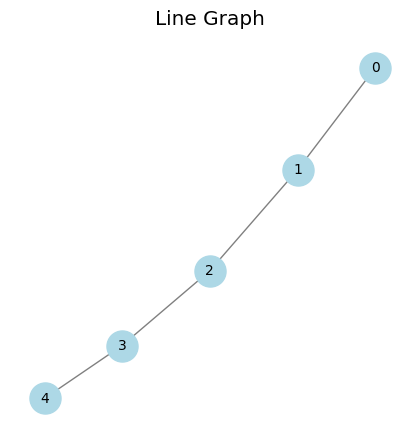

Saved: figures/line_graph.pdf


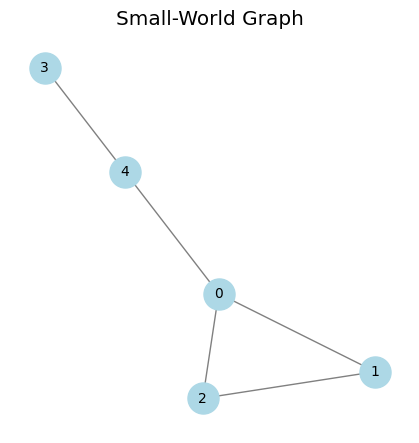

Saved: figures/small_world_graph.pdf


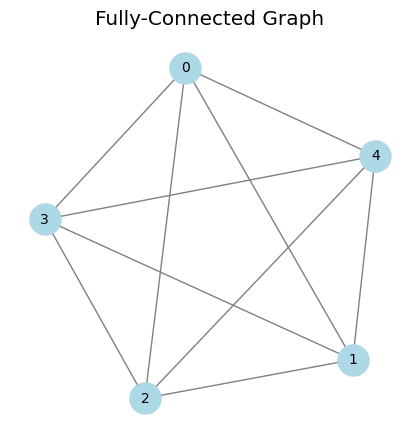

Saved: figures/fully_connected_graph.pdf


In [8]:
import networkx as nx

def make_adj_line(a):
    A = np.zeros((a,a), dtype=int)
    for i in range(a-1):
        A[i,i+1] = 1
        A[i+1,i] = 1
    return A

def make_adj_complete(a):
    return np.ones((a,a), dtype=int) - np.eye(a, dtype=int)

def make_adj_small_world(a, k=1, p=0.4, seed=0):

    rng = np.random.default_rng(seed)
    A = np.zeros((a,a), dtype=int)
    for i in range(a):
        for d in range(1, k+1):
            j = (i+d) % a
            A[i,j] = 1
            A[j,i] = 1
    for i in range(a):
        for d in range(1, k+1):
            j = (i+d) % a
            if i < j and rng.random() < p:
                A[i,j] = A[j,i] = 0
                candidates = [u for u in range(a) if u != i and A[i,u] == 0]
                if candidates:
                    newj = int(rng.choice(candidates))
                    A[i,newj] = A[newj,i] = 1
    return A

def check_connected(A):
    a = A.shape[0]
    seen = set([0])
    stack = [0]
    while stack:
        i = stack.pop()
        for j in range(a):
            if A[i,j] == 1 and j not in seen:
                seen.add(j)
                stack.append(j)
    return len(seen) == a

def metropolis_weights(A):
    a = A.shape[0]
    deg = A.sum(axis=1)
    W = np.zeros((a,a), dtype=float)
    for i in range(a):
        for j in range(a):
            if A[i,j] == 1:
                W[i,j] = 1.0 / (1.0 + max(deg[i], deg[j]))
    for i in range(a):
        W[i,i] = 1.0 - W[i].sum()
    # checks
    assert np.allclose(W, W.T, atol=1e-12)
    assert np.allclose(W.sum(axis=1), 1.0, atol=1e-12)
    return W

A_line = make_adj_line(a)
A_sw   = make_adj_small_world(a, k=1, p=0.4, seed=2)
A_full = make_adj_complete(a)

for name, A_ in [("line",A_line), ("small-world",A_sw), ("fully-connected",A_full)]:
    print(name, "connected?", check_connected(A_), "| edges:", A_.sum()//2)

W_line = metropolis_weights(A_line)
W_sw   = metropolis_weights(A_sw)
W_full = metropolis_weights(A_full)

# Plot the connection graphs
def plot_connection_graph(A, title, out_pdf):
    G = nx.from_numpy_array(A)  # Updated to from_numpy_array
    pos = nx.spring_layout(G, seed=42)  # fixed layout for reproducibility
    plt.figure(figsize=(4, 4))
    nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=500, font_size=10)
    plt.title(title)
    plt.savefig(out_pdf, format="pdf")
    plt.show()
    print("Saved:", out_pdf)

plot_connection_graph(A_line, "Line Graph", FIGURES_DIR / "line_graph.pdf")
plot_connection_graph(A_sw, "Small-World Graph", FIGURES_DIR / "small_world_graph.pdf")
plot_connection_graph(A_full, "Fully-Connected Graph", FIGURES_DIR / "fully_connected_graph.pdf")

## Solve with the 2 distributed methods

1. **Decentralized gradient descent (DGD)**
2. **Gradient tracking (GT)**

In [9]:
def optimality_gap(A_agents, alpha_star):
    # A_agents shape (a,m)
    return np.linalg.norm(A_agents - alpha_star.reshape(1,-1), axis=1)

def local_H_and_b(ag, Kmm, sigma, nu, a):
    K = ag["K_A_m"]
    yloc = ag["y"]
    H = K.T @ K + (sigma**2 / a) * Kmm + (nu / a) * np.eye(Kmm.shape[0])
    b = K.T @ yloc
    return H, b

Hs = []
bs = []
L_list = []
for ag in agents:
    H, b = local_H_and_b(ag, Kmm, sigma, nu, a)
    Hs.append(H); bs.append(b)
    eigs = np.linalg.eigvalsh(H)
    L_list.append(float(eigs[-1]))
Lmax = max(L_list)
print("Lmax (local) =", Lmax)

Lmax (local) = 109.37667115845224


In [10]:
def grad_i(ag, alpha_i, Kmm, sigma, nu, a):
    K = ag["K_A_m"]
    yloc = ag["y"]
    # gradient of local term used in sum_A [...]
    return (sigma**2 / a) * (Kmm @ alpha_i) + (nu / a) * alpha_i + K.T @ (K @ alpha_i - yloc)

def grad_all(agents, A_agents, Kmm, sigma, nu, a):
    G = np.zeros_like(A_agents)
    for i, ag in enumerate(agents):
        G[i] = grad_i(ag, A_agents[i], Kmm, sigma, nu, a)
    return G

def dgd(agents, W, Kmm, sigma, nu, a, alpha_star, T=800, eta=None, seed=0):
    rng = np.random.default_rng(seed)
    aN, m = len(agents), Kmm.shape[0]
    if eta is None:
        eta = 0.2 / Lmax  # conservative
    A = rng.normal(0, 0.1, size=(aN,m))
    gaps = np.zeros((T+1, aN))
    gaps[0] = optimality_gap(A, alpha_star)
    for t in range(T):
        G = grad_all(agents, A, Kmm, sigma, nu, a)
        A = W @ A - eta * G
        gaps[t+1] = optimality_gap(A, alpha_star)
    return A, gaps, eta

def gradient_tracking(agents, W, Kmm, sigma, nu, a, alpha_star, T=800, eta=None, seed=0):
    rng = np.random.default_rng(seed)
    aN, m = len(agents), Kmm.shape[0]
    if eta is None:
        eta = 0.2 / Lmax  # keep conservative (same as DGD)
    A = rng.normal(0, 0.1, size=(aN,m))
    G = grad_all(agents, A, Kmm, sigma, nu, a)
    S = G.copy()
    gaps = np.zeros((T+1, aN))
    gaps[0] = optimality_gap(A, alpha_star)
    for t in range(T):
        A_new = W @ A - eta * S
        G_new = grad_all(agents, A_new, Kmm, sigma, nu, a)
        S = W @ S + (G_new - G)
        A, G = A_new, G_new
        gaps[t+1] = optimality_gap(A, alpha_star)
    return A, gaps, eta


### Plots

In [11]:
def plot_optimality_gaps(gaps, title, out_pdf):
    T = gaps.shape[0]-1
    t = np.arange(T+1)
    plt.figure()
    for i in range(gaps.shape[1]):
        plt.loglog(t[1:], gaps[1:,i], label=f"agent {i+1}")
    plt.xlabel("iterations t")
    plt.ylabel(r"$\|\alpha_i^t - \alpha^*\|$ (gap to optimum)")
    plt.title(title)
    plt.legend(ncol=2)
    plt.grid(True, which="both", ls=":", alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_pdf, format="pdf")
    plt.show()
    print("Saved:", out_pdf)

###  Plot the optimality gap (log-log plot) for one graph



#### Comments (how to read the plot)
- x-axis: iterations (log scale). y-axis: $\|\alpha_i^t-\alpha^*\|$ (log scale).
- Lower curves mean the agent is closer to the centralized solution $\alpha^*$.
- Convergence looks good if curves decrease and all agents end at the same level (consensus).
- Watch $\eta$: too large $\Rightarrow$ oscillations/divergence. Here we use $\eta=0.2/L_{\max}$ (conservative).

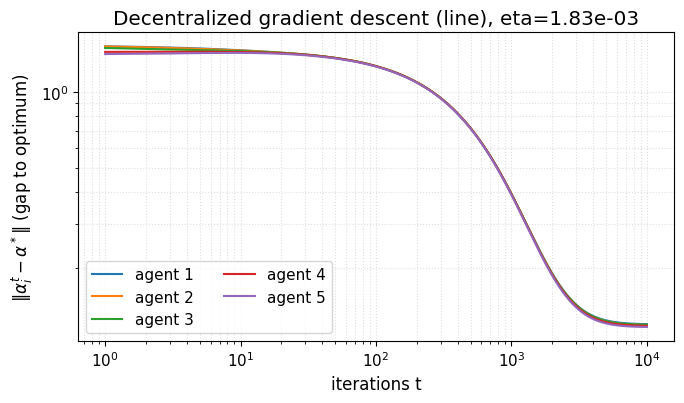

Saved: figures/fig_DGD_line.pdf


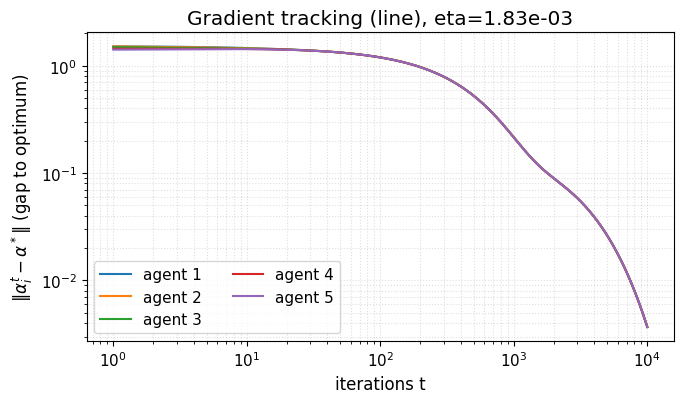

Saved: figures/fig_GT_line.pdf


In [12]:
# Choose a graph here
graph_name = "line"
W = W_line

# Step size: keep it conservative
eta = 0.2 / Lmax

# 1) Decentralized gradient descent
A_dgd, gaps_dgd, _ = dgd(agents, W, Kmm, sigma, nu, a, alpha_star, T=10000, eta=eta)
plot_optimality_gaps(gaps_dgd, f"Decentralized gradient descent ({graph_name}), eta={eta:.2e}",
                     FIGURES_DIR / f"fig_DGD_{graph_name}.pdf")

# 2) Gradient tracking
A_gt, gaps_gt, _ = gradient_tracking(agents, W, Kmm, sigma, nu, a, alpha_star, T=10000, eta=eta)
plot_optimality_gaps(gaps_gt, f"Gradient tracking ({graph_name}), eta={eta:.2e}",
                     FIGURES_DIR / f"fig_GT_{graph_name}.pdf")


### Plot the convergence varying the graph structure



#### Comments (graph influence)
- A more **connected** graph mixes information faster (matrix $W$), so convergence is usually faster.
- Typical ranking: **fully-connected** $>$ **small-world** $>$ **line** (the last is the slowest).
- With the same parameters, *Gradient Tracking* is often more robust/faster than DGD on poorly connected graphs.

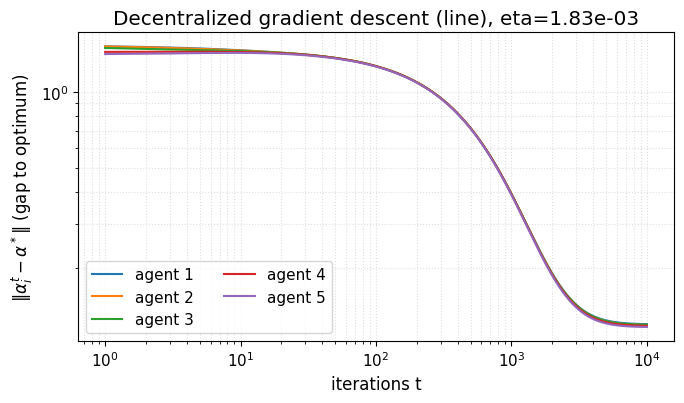

Saved: figures/fig_DGD_line.pdf


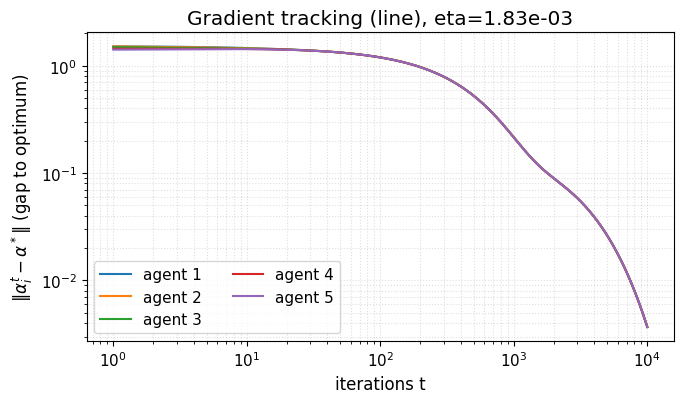

Saved: figures/fig_GT_line.pdf


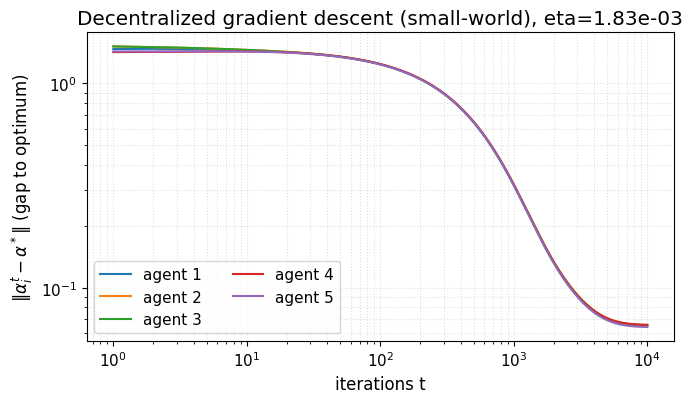

Saved: figures/fig_DGD_small-world.pdf


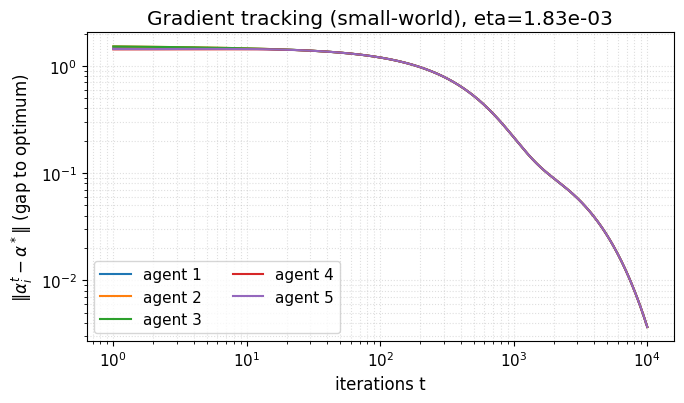

Saved: figures/fig_GT_small-world.pdf


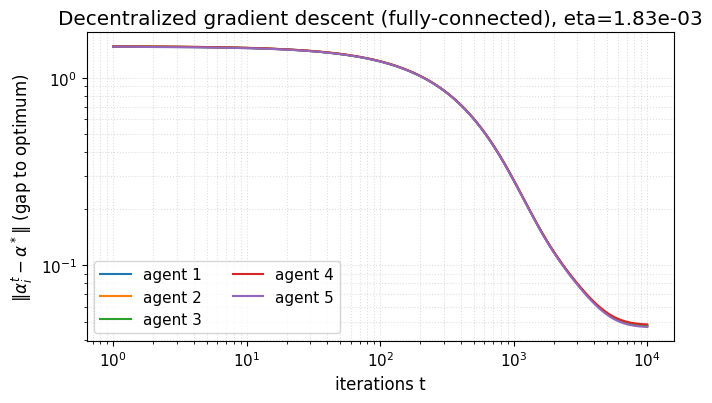

Saved: figures/fig_DGD_fully-connected.pdf


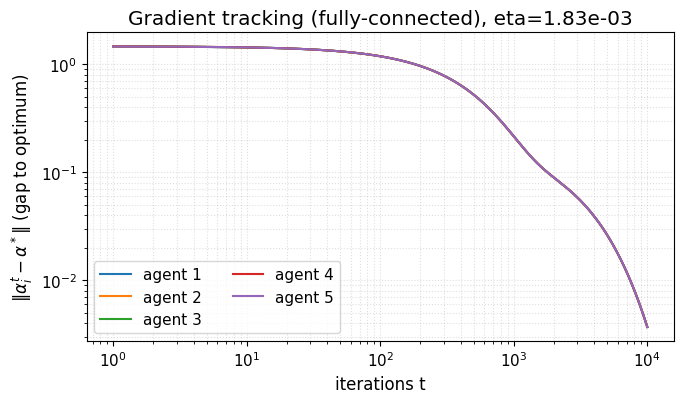

Saved: figures/fig_GT_fully-connected.pdf


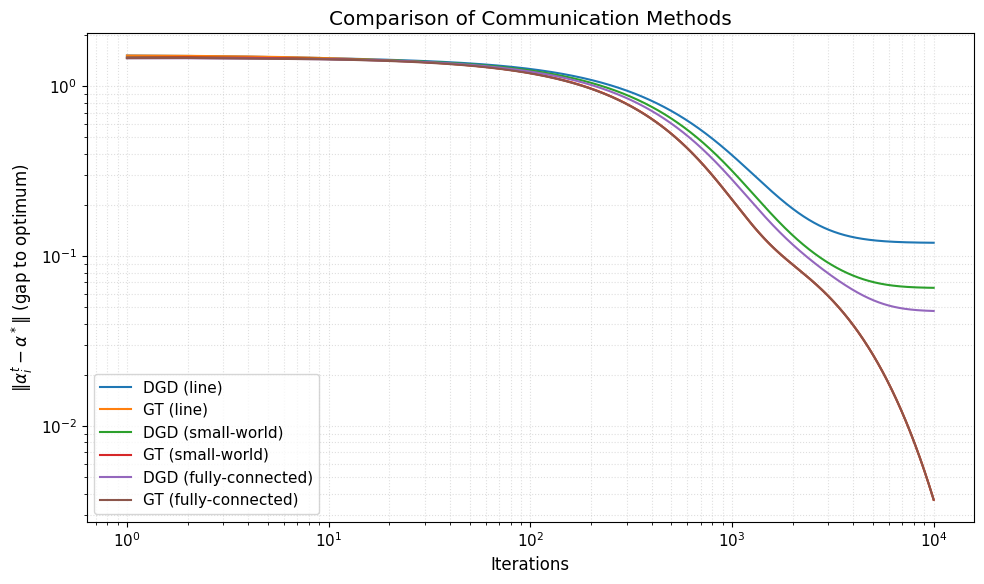

Saved: figures/fig_communication_methods_comparison.pdf


In [13]:
def run_all_methods_on_graph(graph_name, W, *, eta=None):
    if eta is None:
        eta = 0.2 / Lmax

    # DGD
    _, gaps_dgd, _ = dgd(agents, W, Kmm, sigma, nu, a, alpha_star, T=10000, eta=eta, seed=0)
    plot_optimality_gaps(gaps_dgd, f"Decentralized gradient descent ({graph_name}), eta={eta:.2e}",
                         FIGURES_DIR / f"fig_DGD_{graph_name}.pdf")

    # GT
    _, gaps_gt, _ = gradient_tracking(agents, W, Kmm, sigma, nu, a, alpha_star, T=10000, eta=eta, seed=0)
    plot_optimality_gaps(gaps_gt, f"Gradient tracking ({graph_name}), eta={eta:.2e}",
                         FIGURES_DIR / f"fig_GT_{graph_name}.pdf")

# Run on the three graphs
run_all_methods_on_graph("line", W_line)
run_all_methods_on_graph("small-world", W_sw)
run_all_methods_on_graph("fully-connected", W_full)


# Compare communication methods for the same problem
def compare_communication_methods(graphs, graph_names, agents, Kmm, sigma, nu, a, alpha_star, T=10000, eta=None):
    if eta is None:
        eta = 0.2 / Lmax

    plt.figure(figsize=(10, 6))
    for graph, name in zip(graphs, graph_names):
        W = metropolis_weights(graph)
        _, gaps_dgd, _ = dgd(agents, W, Kmm, sigma, nu, a, alpha_star, T=T, eta=eta, seed=0)
        plt.loglog(range(1, T+1), gaps_dgd[1:, 0], label=f"DGD ({name})")

        _, gaps_gt, _ = gradient_tracking(agents, W, Kmm, sigma, nu, a, alpha_star, T=T, eta=eta, seed=0)
        plt.loglog(range(1, T+1), gaps_gt[1:, 0], label=f"GT ({name})")

    plt.xlabel("Iterations")
    plt.ylabel(r"$\|\alpha_i^t - \alpha^*\|$ (gap to optimum)")
    plt.title("Comparison of Communication Methods")
    plt.legend()
    plt.grid(True, which="both", ls=":", alpha=0.4)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig_communication_methods_comparison.pdf", format="pdf")
    plt.show()
    print("Saved:", FIGURES_DIR / "fig_communication_methods_comparison.pdf")

# Define the graphs and their names
graphs = [A_line, A_sw, A_full]
graph_names = ["line", "small-world", "fully-connected"]

# Run the comparison
compare_communication_methods(graphs, graph_names, agents, Kmm, sigma, nu, a, alpha_star, T=10000, eta=0.2 / Lmax)


### Visualize the obtained functions on a uniform grid (`nt = 250`)

$$
f(x) \approx \sum_{j\in M}\alpha_j k(x, x_j).
$$


#### Comments (effect of $n$)
- All curves use the same set of $m$ landmark points (fixed) to make the comparison across $n$ meaningful.
- As $n$ increases, the reconstructed function should get closer to the reference curve.
- Training points (up to the maximum $n$ shown) are displayed for context.

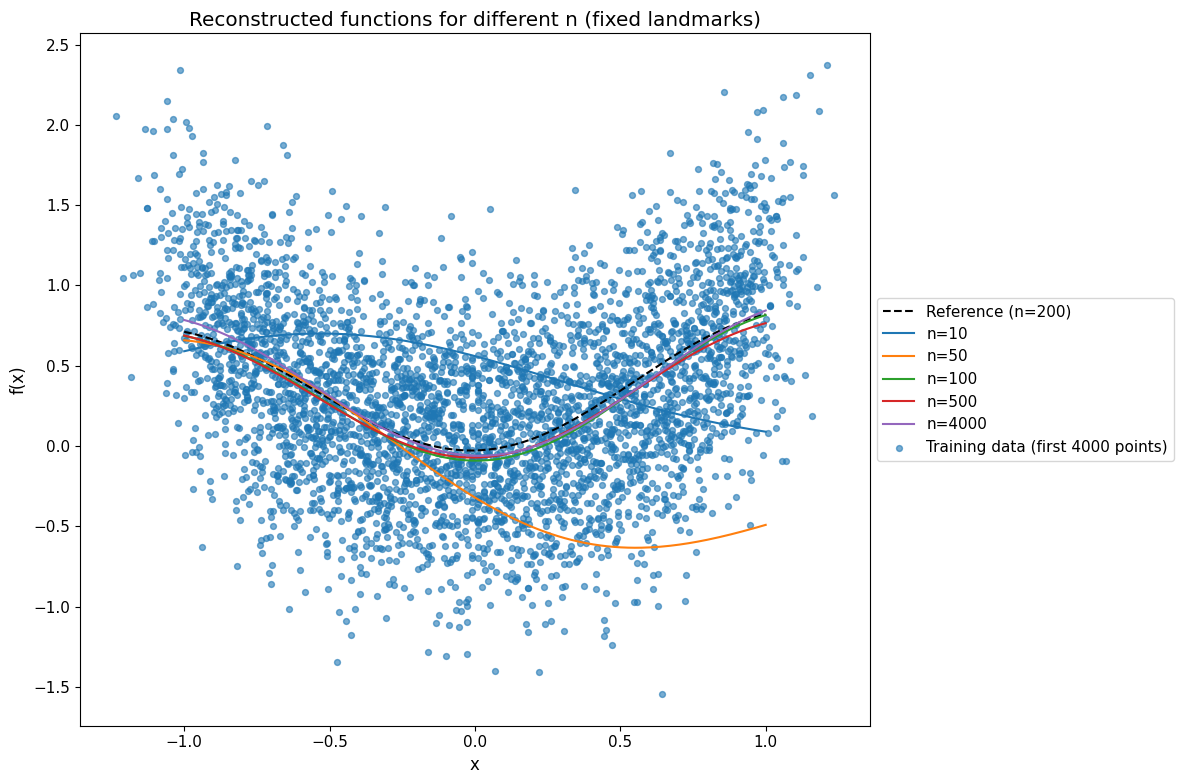

Saved: figures/fig_functions_multiple_n_with_reference.pdf


In [14]:
# Centralized reconstructed functions for different n (fixed landmarks)

def f_from_alpha(alpha, x_query, x_selected):
    return K_nm(x_query, x_selected) @ alpha

reference_n = 200
n_values = [10, 50, 100, 500,4000]  # values of n to compare (excluding the reference)

nt = 250
x_prime = np.linspace(-1, 1, nt)

# Fix the landmark points (m points) once, using the first reference_n samples
rng_compare = np.random.default_rng(1)
x_ref = x_all[:reference_n].copy()
y_ref = y_all[:reference_n].copy()
ind_ref = rng_compare.choice(reference_n, m, replace=False)
x_selected_fixed = x_ref[ind_ref]

Kmm_fixed = K_nm(x_selected_fixed, x_selected_fixed)

# Reference curve (n = reference_n)
Knm_ref = K_nm(x_ref, x_selected_fixed)
alpha_star_ref = centralized_alpha_star(Kmm_fixed, Knm_ref, y_ref, sigma=sigma, nu=nu)
f_star_ref = f_from_alpha(alpha_star_ref, x_prime, x_selected_fixed)

plt.figure(figsize=(12, 8))
plt.plot(x_prime, f_star_ref, label=f"Reference (n={reference_n})", linestyle="--", color="black")

for n in n_values:
    x_n = x_all[:n].copy()
    y_n = y_all[:n].copy()

    Knm_n = K_nm(x_n, x_selected_fixed)
    alpha_star_n = centralized_alpha_star(Kmm_fixed, Knm_n, y_n, sigma=sigma, nu=nu)
    f_star_n = f_from_alpha(alpha_star_n, x_prime, x_selected_fixed)

    plt.plot(x_prime, f_star_n, label=f"n={n}")

max_n = max([reference_n] + n_values)
plt.scatter(x_all[:max_n], y_all[:max_n], s=18, alpha=0.6, label=f"Training data (first {max_n} points)")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Reconstructed functions for different n (fixed landmarks)")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_functions_multiple_n_with_reference.pdf", format="pdf")
plt.show()
print("Saved:", FIGURES_DIR / "fig_functions_multiple_n_with_reference.pdf")
